# Composite Shapes

In this example a composite section is built by joining multiple basic shapes.

In [1]:
from xsection import CompositeSection
from xsection.library import Circle, Equigon
from xara.units.iks import inch, foot, ksi, kip 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from xara import Material, Section

# Define materials
materials = {
    "core": Material(
        type = "Concrete02",
        Fc  =   7.08*ksi,
        nu  =  0.2,
        ec0 =  0.00295,
        Fcu =  5*ksi,
        ecu =  0.014
    ),
    "cover": Material(
        type = "Concrete02",
        Fc  =   -6.5*ksi,
        nu  =   0.2,
        ec0 =  -0.002,
        Fcu =  -0.5*ksi,
        ecu =  -0.005,
        # "lambda": 0.1,
        # "Ft": 0.65*ksi,
        # "Ets": 500. # Tension stiffening
    ),
    "rebar": Material(
        type = "Steel01",
        nu = 0.3,
        E  =   29e3*ksi,
        Fy =     40*ksi,
        b =   0.05
    )
}

## Concrete Circle

We begin by specifying the dimensions of our section.

In [3]:

d =  7/8*inch
ds = 2/8*inch # diameter of the shear spiral
cover = 1*inch + ds
diameter = 15*inch
core_radius = diameter/2 - cover - ds - d/2
nr = 20 # number of longitudinal reinforcing bars


Next we'll create the shapes which make up our composite geometry.

To handle overlapping regions, each shape is assigned an integer index `z`. When two shapes overlap, the one with the larger `z` takes priority.

This mechanism allows us to represent the *cover* and *core* regions. We first create a circle exterior with `z=0` to represent the cover. Next, we define the *core* as another circle with a smaller radius but larger `z` (here `z=1`). Because of the higher `z` value, the core “cuts out” the corresponding area from the cover.

Like all simple shapes in `xsection`, the `Circle` class is just a wrapper around the `Polygon` shape. For this reason, we use the `divisions` argument to indicate how many polygon edges should be used to approximate the smooth geometry of a circle. 

The `mesh_scale` argument dictates roughly how many integration points should be generated within the shape.

In [4]:
# Define the exterior shape
exterior = Circle(diameter/2, z=0,
                  material=materials["cover"],
                  group="cover", 
                  divisions=60, mesh_scale=1/80)

interior = Equigon(core_radius, z=1,
                   material=materials["core"],
                   group="core", divisions=nr, mesh_scale=1/20)



The reinforcing bars are defined separately as small circles. Because stresses generally don't vary drastically within individual reinforcing bars, we'll use a much coarser circle approximation by setting `divisions=4` and `mesh_scale=2`.

The location of the first bar is given explicitly, and the remaining bars are generated automatically by evenly spacing them around the core.

In [5]:
# A single representative rebar
one_bar = Circle(d/2, z=2, 
                 material=materials["rebar"],
                 mesh_scale=1/2, divisions=4, group="rebar")

# Location of the first bar; the rest will be generated 
# by linearly spacing them around an arc 
xr = ((diameter/2) - cover - ds - d/2, 0)

bars = one_bar.linspace(xr, xr, nr, endpoint=False, center=(0,0))

Finally, we assemble all parts—the cover (`interior`), the core (`exterior`), and the bars—into a single [`CompositeSection`](https://peer-open-source.github.io/xsection/api/composite/xsection.CompositeSection.html).

In [6]:
# Create the composite section
shape = CompositeSection([
            exterior,
            interior,
            *bars
        ])

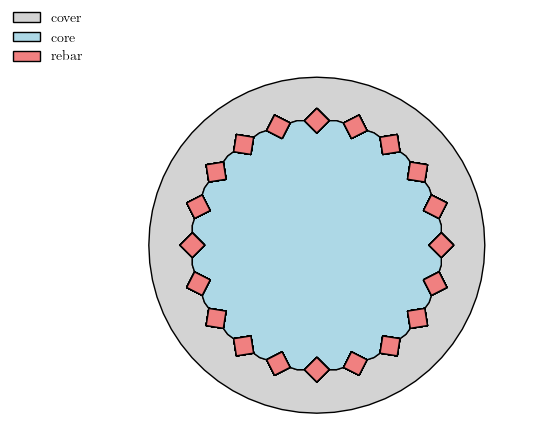

In [7]:
import veux

# artist = veux.create_artist(shape.model)
# # artist.draw_samples()
# artist.draw_outlines()
# artist.draw_surfaces()
# artist
veux.draw_shape(shape)

## Rectangle

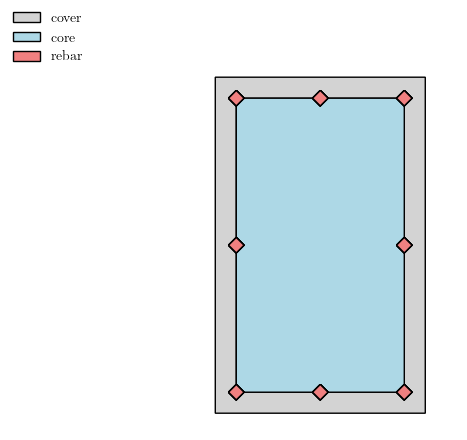

In [8]:
from xsection.library import Rectangle, Circle
from xsection import CompositeSection

h = 24
b = 15
d = 7/8
r = 0 #d/2

c = 1.5

bar = Circle(d/2, z=2, 
             material=materials["rebar"],
             mesh_scale=1/2, divisions=4, group="rebar")

shape = CompositeSection([
            Rectangle(    b, h,     z=0, group="cover", material=materials["cover"]),
            Rectangle(b-2*c, h-2*c, z=1, group="core", material=materials["core"]),
            *bar.linspace([-b/2+c+r, -h/2+c+r], [ b/2-c-r,-h/2+c+r], 3), # Top bars
            *bar.linspace([-b/2+c+r,        0], [ b/2-c-r,       0], 2), # Center bars
            *bar.linspace([-b/2+c+r,  h/2-c-r], [ b/2-c-r, h/2-c-r], 3)  # Bottom bars
        ])



veux.draw_shape(shape)